In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Overview

In [4]:
df = pd.read_csv('train.csv')
df.head()
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Observations:
### The dataset contains 891 samples and 12 variables, including both numerical and categorical features.
### Missing values:
#### Age: 177 missing values
#### Cabin: 687 missing values
#### Embareked: 2 missing values
### Survival: The overall survival rate is about 38.38%.
### Pclass: Most passengers belong to class 2 and class 3.
### Age: The passengers were mostly young adults.
### SibSp and Parch: Most passengers traveled alone or with one companions.
### Fare: The fare prices really spread out with a wide range from 0 to around 512.

# Exploratory Data Analysis

## Gender Analysis

        Total_count  Survived_count  Survival_rate
Sex                                               
female          314             233       0.742038
male            577             109       0.188908


(array([0, 1]), [Text(0, 0, 'female'), Text(1, 0, 'male')])

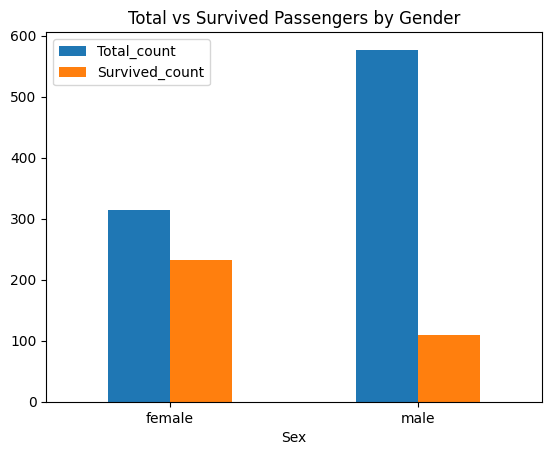

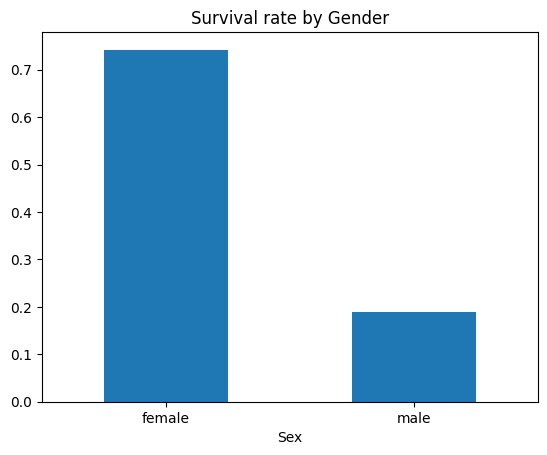

In [6]:
df_gender = df.groupby('Sex').agg(
    Total_count  = ('Sex','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
)
print(df_gender)

df_gender[['Total_count','Survived_count']].plot(kind='bar')
plt.title('Total vs Survived Passengers by Gender')
plt.xticks(rotation = 0)
plt.figure()
df_gender['Survival_rate'].plot(kind='bar')
plt.title('Survival rate by Gender')
plt.xticks(rotation = 0)

### Observations：
#### Although the  number of male passengers was almost twice higher than females, female passengers accounted for the majority of survivors, and the survival rate of females(74.20%) was significantly higher than males(18.90). This indicates that gender is a strong feature to the model.

### Reasons: The reason might be the woman and children first principle, later in the age analysis, I will examine whether the children also have higher survival rate.

## Pcalss Analysis

        Total_count  Survived_count  Survival_rate
Pclass                                            
1               216             136       0.629630
2               184              87       0.472826
3               491             119       0.242363


(array([0, 1, 2]), [Text(0, 0, '1'), Text(1, 0, '2'), Text(2, 0, '3')])

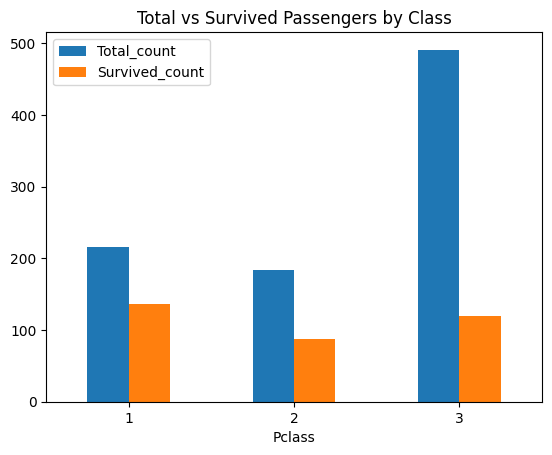

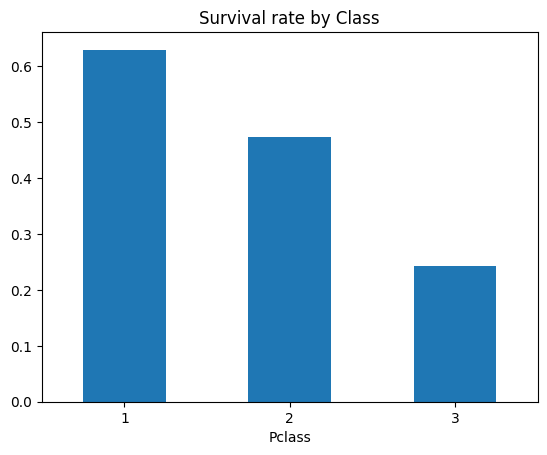

In [10]:
df_pclass = df.groupby('Pclass').agg(
    Total_count = ('Pclass','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
)
print(df_pclass)

df_pclass[['Total_count','Survived_count']].plot(kind='bar')
plt.title('Total vs Survived Passengers by Class')
plt.xticks(rotation = 0)
plt.figure()
df_pclass['Survival_rate'].plot(kind='bar')
plt.title('Survival rate by Class')
plt.xticks(rotation = 0)

### Observations:
#### Class 3 had the highest number of passengers but the lowest survival rate. There is a positive correlation between Pclass and survival rate:The higher the class, the higher survival rate.

### Reasons:
#### Priority: Passengers in class 1 may have privileges during evacuation, they have the priority to resources. Moreover, the crew may put the safety of class 1 before other classes, like passengers in class 1 can receive better guidance.
#### Location:  First class was usually on the upper decks which allow then to quickly get life saving resources and more simple escape route.

## Age Analysis

Text(0.5, 1.0, 'The Age Distribution')

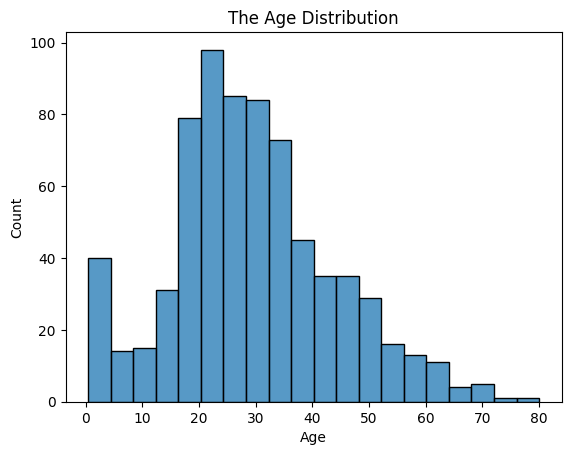

In [31]:
# Observe the age distribution
sns.histplot(df.Age)
plt.title('The Age Distribution')

### Missing value: 
#### Corresponding to the observation in data overview, the distribution of the age is right skewed and is concentrated in 15-35 age range.
#### Since the Name field gives the detailed titles, it provides a rough age range, so here I use median of the corresponding title group to fill in the missing values.

Title
Mr        119
Miss       36
Mrs        17
Master      4
Dr          1
Name: count, dtype: int64
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket 

Text(0.5, 1.0, 'The Filled Age Distribution')

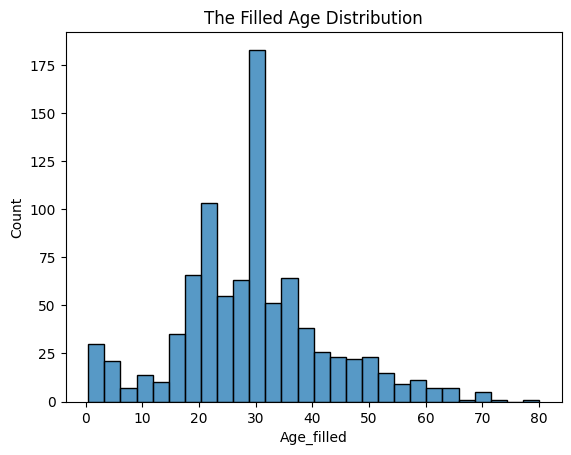

In [52]:
# Extract the title field
df['Title'] = df.Name.apply(lambda x:x.split(',')[1].split('.')[0].strip())
df.head()
df['Title'].isnull().any()
# Observe titles of missing value
print(df.Title[df.Age.isnull()].value_counts())
print(df.Title.value_counts())
# Fill in missing values
df['Age_filled'] = df.groupby('Title')['Age'].transform(lambda x:x.fillna(x.median()))
df.info()
# Observe the age_filled distribution
sns.histplot(df.Age_filled)
plt.title('The Filled Age Distribution')

### By Comparing the title distribution of missing samples and overall samples, I find the missing values focus on the most frequent titles like Mr, Miss, Mrs and Master. After filling, the age distribution still concentrate in the 15 - 35 age range and remains right skewed which is consistent with the title distribution of missing values.

           Total_count  Survived_count  Survival_rate
Age_group                                            
Children            64              38       0.593750
Teenager            75              32       0.426667
Adult              553             215       0.388788
Senior             199              57       0.286432


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Children'),
  Text(1, 0, 'Teenager'),
  Text(2, 0, 'Adult'),
  Text(3, 0, 'Senior')])

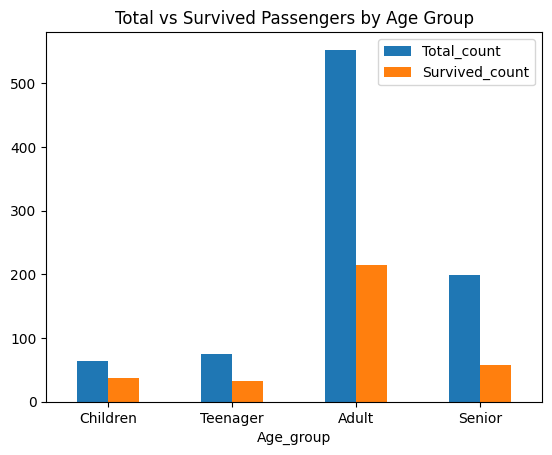

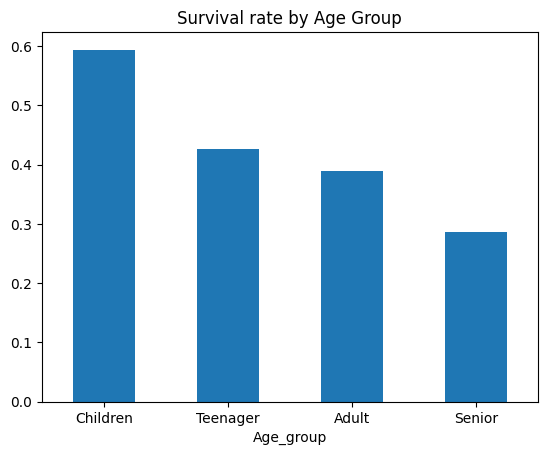

In [51]:
# Age grouping
def age_grouping(age):
    if age <= 10:
        return 'Children'
    elif age <= 18:
        return 'Teenager'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Senior'
df['Age_group'] = df.Age.apply(age_grouping)

df_age = df.groupby('Age_group').agg(
    Total_count = ('Age_group','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
).sort_values(by='Survival_rate',ascending=False)
print(df_age)

df_age[['Total_count','Survived_count']].plot(kind='bar')
plt.title('Total vs Survived Passengers by Age Group')
plt.xticks(rotation = 0)
plt.figure()
df_age['Survival_rate'].plot(kind='bar')
plt.title('Survival rate by Age Group')
plt.xticks(rotation = 0)

### Observations:
#### The bar chart shows a decline in survival rate as age increases and the survival rate of children(almost 60%) is nearly double of the senior group.
#### What's more, as the adult passengers account for the majority of the samples, its survival rate(38.88%) is close to the overall(38.38%).
### Reasons: The reason might be the woman and children first principle.

## SibSp and Parch Analysis

Family
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64


(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '5'),
  Text(5, 0, '4'),
  Text(6, 0, '6'),
  Text(7, 0, '10'),
  Text(8, 0, '7')])

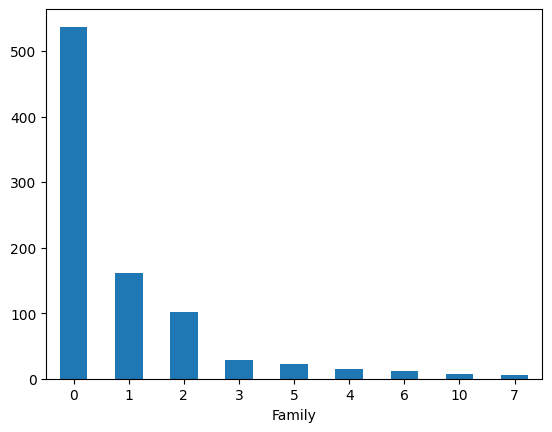

In [60]:
# Merge the SibSp and Parch columns to get the total number of family members
df['Family'] = df.SibSp + df.Parch
print(df.Family.value_counts())
df.Family.value_counts().plot(kind='bar')
plt.xticks(rotation = 0)

### The distribution of Family shows that most passengers traveled alone and there is a obvious gap from 102(2 companions) to 29(3 companions), so I divide passengers to 3 groups to examine whether there is a difference between different groups.
#### Travel alone: 0
#### Travel with <=2 family members
#### Travel with >=3 family members

             Total_count  Survived_count  Survival_rate
Family_Size                                            
1                    263             148       0.562738
2                     91              31       0.340659
0                    537             163       0.303538


(array([0, 1, 2]), [Text(0, 0, '1'), Text(1, 0, '2'), Text(2, 0, '0')])

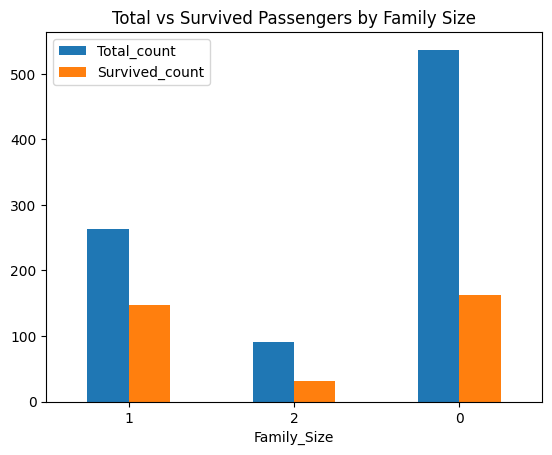

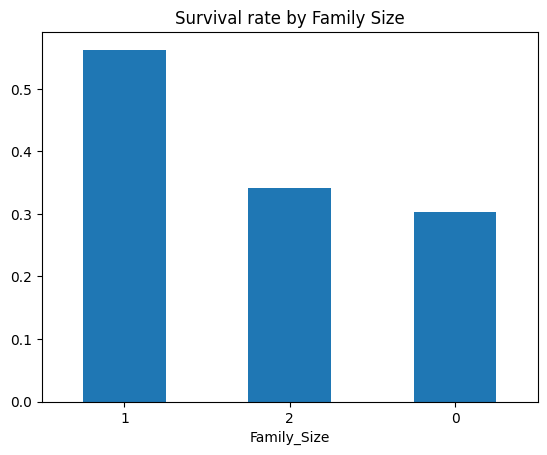

In [76]:
# Family grouping
df['Family_Size'] = df.Family.apply(lambda x:0 if x == 0 else (1 if x <=2 else 2))
df_FamilySize = df.groupby('Family_Size').agg(
    Total_count = ('Family_Size','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
).sort_values(by='Survival_rate',ascending=False)
print(df_FamilySize)

df_FamilySize[['Total_count','Survived_count']].plot(kind='bar')
plt.title('Total vs Survived Passengers by Family Size')
plt.xticks(rotation = 0)
plt.figure()
df_FamilySize['Survival_rate'].plot(kind='bar')
plt.title('Survival rate by Family Size')
plt.xticks(rotation = 0)

### Observations: 
#### Passengers accompanied with 1 - 2 family members has a significant higher survival rate than passengers who traveled alone or with more than 3 companions.
### Reasons:
#### Mutual assistance: improve survivial chances among family with small size.
#### Low efficiency: may struggle to ensure everyone's safety among family with large size.

## Fare Analysis

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

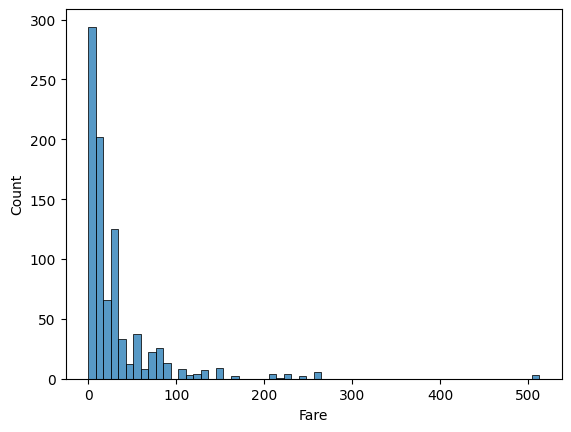

In [93]:
# Observe the fare distribution
sns.histplot(df.Fare)
df.Fare.describe()

### The distribution is right skewed and has a few extreme high values. These outliers affect the mean, std_dev and also make it difficult to observe the fares between 0 - 100 clearly, the range where prices are concentrated. Therefore, we use log to compress extreme values.

count    891.000000
mean       2.962246
std        0.969048
min        0.000000
25%        2.187218
50%        2.737881
75%        3.465736
max        6.240917
Name: log_fare, dtype: float64


C:\Users\56864\AppData\Local\Temp\ipykernel_40772\3227700267.py:5: RuntimeWarning: overflow encountered in exp
  df.log_fare.describe().apply(lambda x:np.exp(x)-1)


count           inf
mean      18.341359
std        1.635435
min        0.000000
25%        7.910388
50%       14.454200
75%       31.000000
max      512.329200
Name: log_fare, dtype: float64

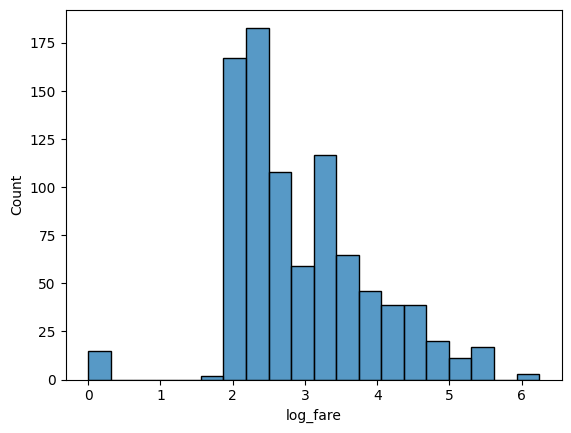

In [100]:
# log transformation
df['log_fare'] = df.Fare.apply(np.log1p)
sns.histplot(df.log_fare,bins = 20)
print(df.log_fare.describe())
df.log_fare.describe().apply(lambda x:np.exp(x)-1)

### After transformation, the mean is about 18.34 which is lower than the original mean 32.2, and it is close to the median 14.45, so the dataset is more concentrated and the impact of outliers is reduced.

<Axes: xlabel='Survived', ylabel='log_fare'>

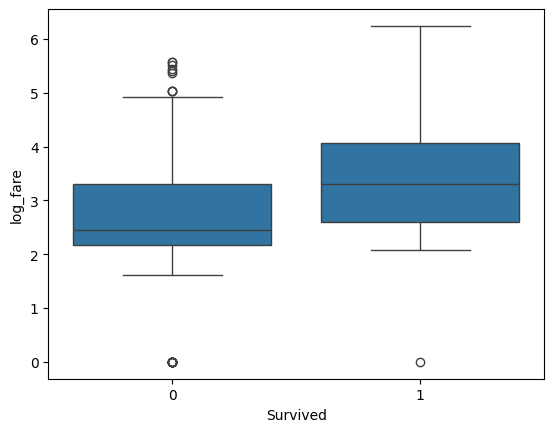

In [101]:
# Boxplot of log_fare by survival status
sns.boxplot(x='Survived',y='log_fare',data=df)

### Observations:
#### The median fare of survivors is significantly higher than the died group which means passengers who paid higher fare price are more likely to survive.
#### It seemes related to the Pclass analysis like high-spending groups have priority, so I need to analyze whether the the difference in fare is a consequence of the Pclass.

## Embarked Analysis

In [110]:
# Missing value
df['class_1'] = df.Pclass.apply(lambda x:1 if x == 1 else 0)
df_port_class1 = df.groupby('Embarked')['class_1'].agg(total_count = 'count', class1_count = 'sum', rate = 'mean')
print(df_port_class1)
df['Embarked_filled'] = df.Embarked.fillna('C')
df.info()

          total_count  class1_count      rate
Embarked                                     
C                 168            85  0.505952
Q                  77             2  0.025974
S                 644           127  0.197205
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    str    
 4   Sex              891 non-null    str    
 5   Age              714 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    str    
 9   Fare             891 non-null    float64
 10  Cabin            204 non-null    str    
 11  Embarked         889 non-null    str    
 12  Title            891 non-nu

### Missing value:
#### When using filters to explore the port data, I find passengers from port Q are almost from class 3, so I assume different port reflects different economic backgrounds of passengers.
#### The two missing values were all from class 1, so I decided to fill in the values using port which has the highest proportion of class 1.

                 Total_count  Survived_count  Survival_rate
Embarked_filled                                            
C                        170              95       0.558824
Q                         77              30       0.389610
S                        644             217       0.336957


(array([0, 1, 2]), [Text(0, 0, 'C'), Text(1, 0, 'Q'), Text(2, 0, 'S')])

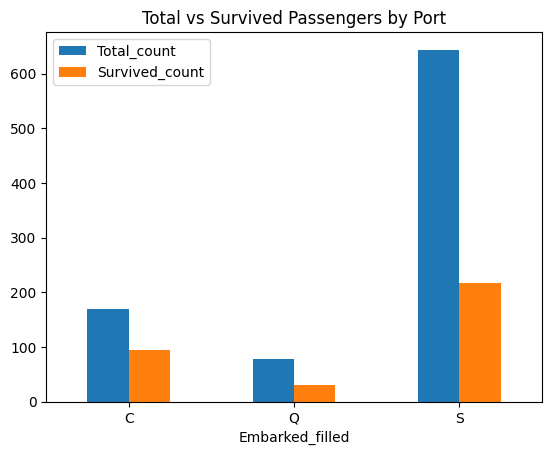

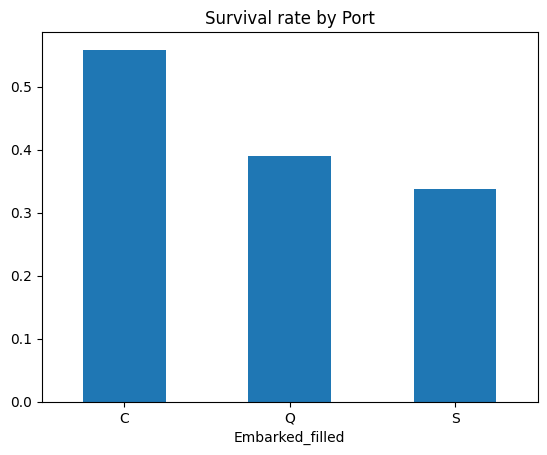

In [118]:
df_port = df.groupby('Embarked_filled').agg(
    Total_count = ('Embarked_filled','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
)
print(df_port)

df_port[['Total_count','Survived_count']].plot(kind='bar')
plt.title('Total vs Survived Passengers by Port')
plt.xticks(rotation = 0)
plt.figure()
df_port['Survival_rate'].plot(kind='bar')
plt.title('Survival rate by Port')
plt.xticks(rotation = 0)

### Observations:
#### Port C with the highest proportion of class 1 also has the highest survival rate, but when it comes to port Q and port S, the distribution of pclass can not explain why port Q with almost all passengers from class 3 has a slight higer survival rate than port S. 
#### I need to explore what result in the contradiction, was it gender or other factors.

## Fare & Pclass Analysis

<Axes: xlabel='Pclass', ylabel='log_fare'>

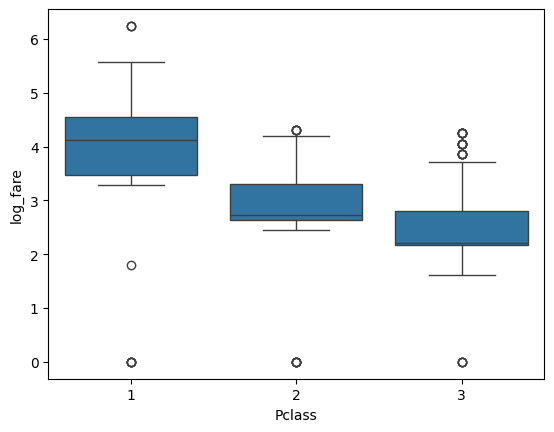

In [ ]:
# Relationship between fare and pclass
sns.boxplot(x='Pclass',y='log_fare',data=df)

### Observations:
#### The boxplot indicates fare price is significant different among different classes.
#### In class 2 and class 3, the mean is significantly higher than the median, indicating fares in class 2 and 3 vary widely.
#### Outliers in class 3: why passengers in class 3 pay higher prices? — When I use the filter in excel to check the passengers in class 3 with the highest price(69.55), I find all of them are from the Sage family, so the ticket price may be the total fare for the family rather than the average price allocated to each family member.
#### Solution: Using the fare price divided by the number of family menmbers.

<Axes: xlabel='Survived', ylabel='log_fare2'>

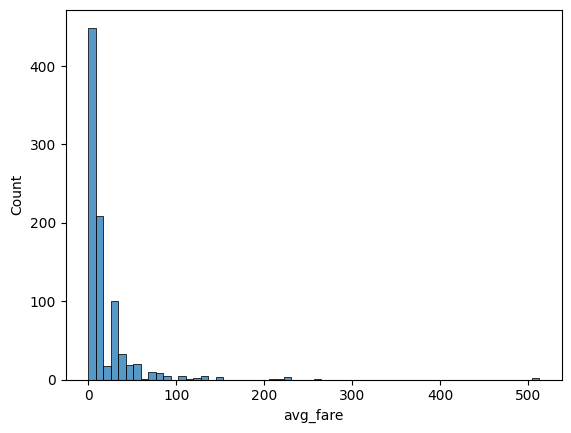

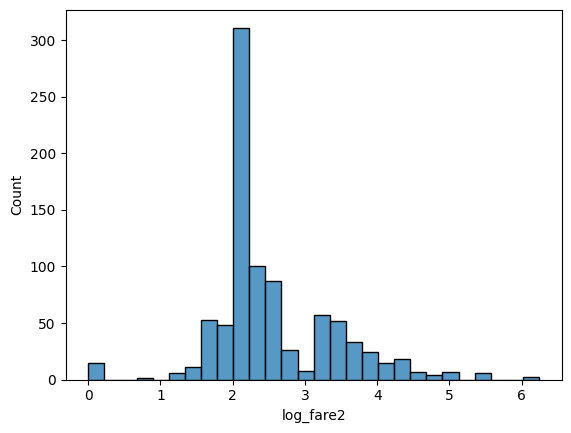

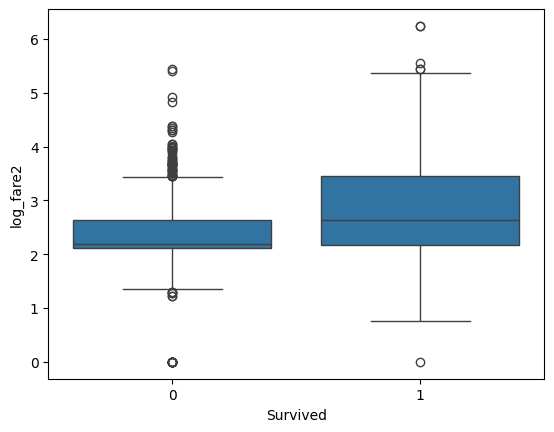

In [126]:
# Re-analysis of fares
df['avg_fare'] = df.Fare / (df.Family + 1)
sns.histplot(df.avg_fare)
df['log_fare2'] = df.avg_fare.apply(np.log1p)
plt.figure()
sns.histplot(df.log_fare2)
plt.figure()
sns.boxplot(x='Survived',y='log_fare2',data=df)

### The histplot for log_fare2 is more concentrated and the number of samples paying high fare price decrease which indicates that average price reduce the influence from extreme high prices.
### There still exist a price difference between survivors and died passengers.
### Outliers in non-survived group increase a lot — Although these passengers pay a high fare price, they still cannot survive.

<Axes: xlabel='Pclass', ylabel='log_fare2'>

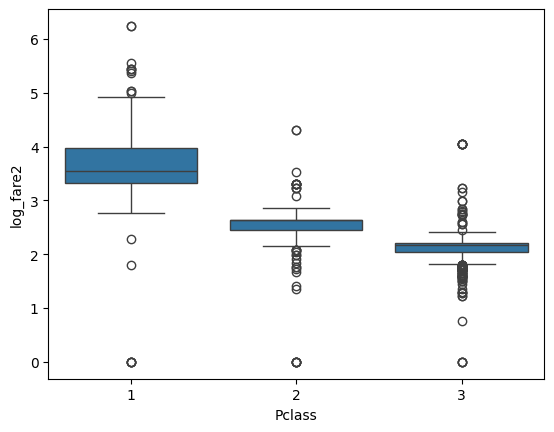

In [127]:
# Re-analysis relationship between fare and pclass 
sns.boxplot(x='Pclass',y='log_fare2',data=df)

### By averaging the fare price, the distribution is more concentrated so the body of box is smaller than before.
### The fare differnece is significant among different classes.

Text(0.5, 1.0, 'Survival Effects of Fare in Pclass 3')

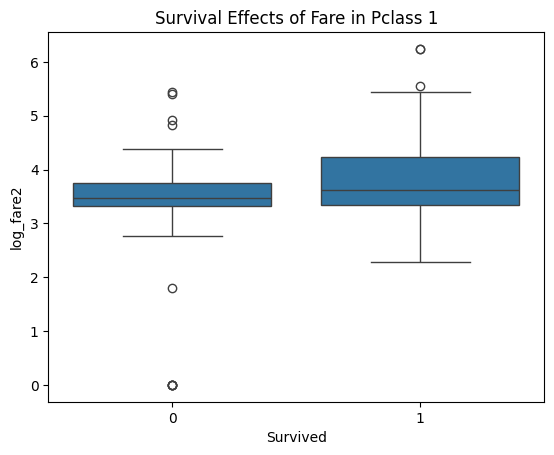

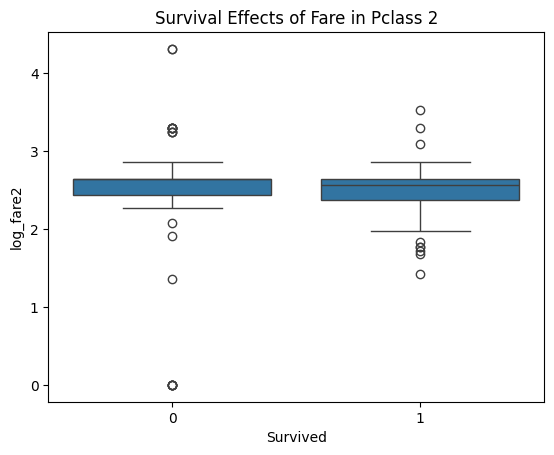

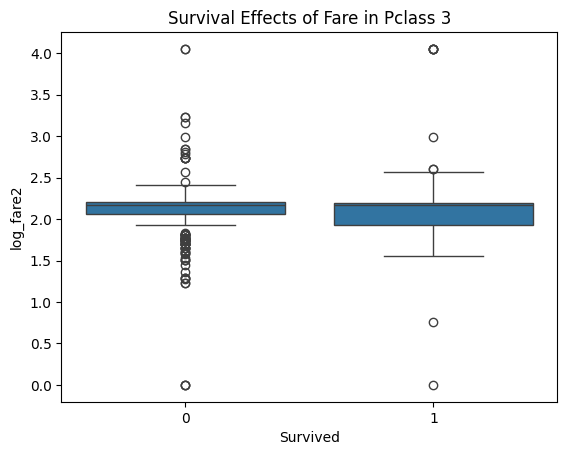

In [130]:
# Survival effects of fare with fixed class
sns.boxplot(x='Survived',y='log_fare2',data=df[df.Pclass == 1])
plt.title('Survival Effects of Fare in Pclass 1')
plt.figure()
sns.boxplot(x='Survived',y='log_fare2',data=df[df.Pclass == 2])
plt.title('Survival Effects of Fare in Pclass 2')
plt.figure()
sns.boxplot(x='Survived',y='log_fare2',data=df[df.Pclass == 3])
plt.title('Survival Effects of Fare in Pclass 3')

### Observations:
#### Pclass 1: The mean and median in survival group is obvious higher than non-survival group.The survival group has higher upper limit which means people who pays extreme high price survivrd. The box of died group concentrated in relatively lower price range in class 1.
#### Pclass 2: The median of survivors in class 2 even lower than death group. Is there some other factors infulence class 2?
#### Pclass 3: The median of survivors almost the same as death group and there are plenty of upper outliers in death group which means even paying a higher price, passengers still cannot survive.
#### Overall: The price is only significant in class 1, if the passenger was in class 2 and 3, the higher price will not provide a higher possibility to survive and it seems that some other factors have more impact.

## Pclass & Gender Analysis

        Total_count  Survived_count  Survival_rate
Sex                                               
female           94              91       0.968085
male            122              45       0.368852
        Total_count  Survived_count  Survival_rate
Sex                                               
female           76              70       0.921053
male            108              17       0.157407
        Total_count  Survived_count  Survival_rate
Sex                                               
female          144              72       0.500000
male            347              47       0.135447


<Figure size 640x480 with 0 Axes>

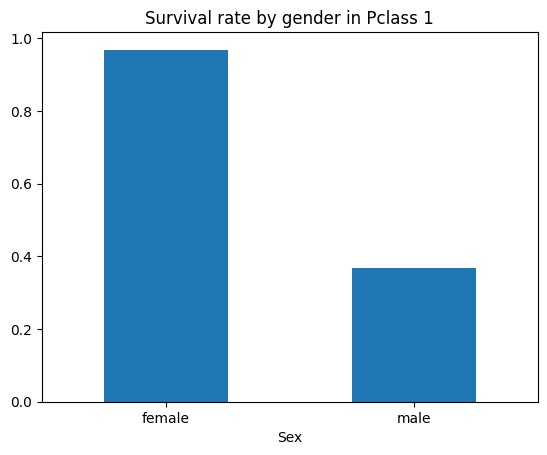

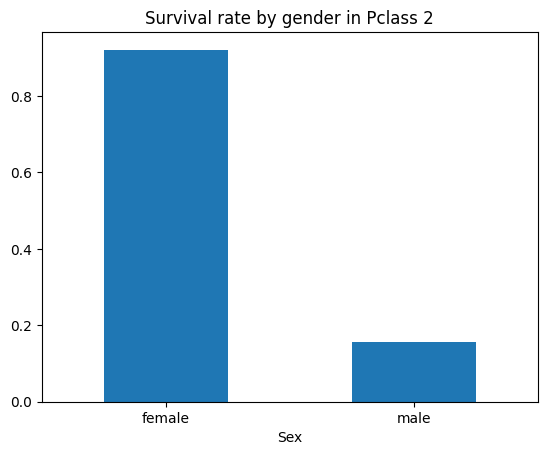

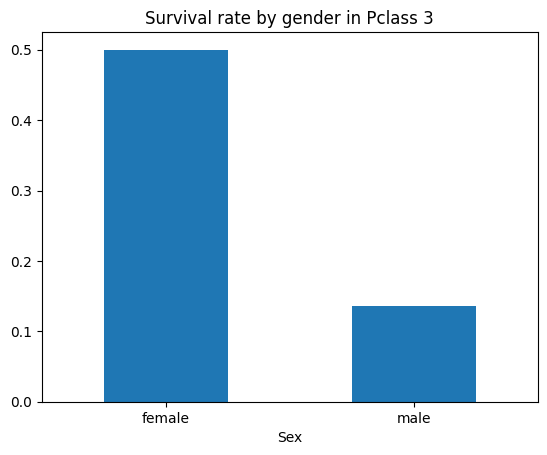

<Figure size 640x480 with 0 Axes>

In [ ]:
df_pclass1 = df[df.Pclass == 1].groupby('Sex').agg(
    Total_count = ('Sex','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
)
print(df_pclass1)

df_pclass2 = df[df.Pclass == 2].groupby('Sex').agg(
    Total_count = ('Sex','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
)
print(df_pclass2)

df_pclass3 = df[df.Pclass == 3].groupby('Sex').agg(
    Total_count = ('Sex','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
)
print(df_pclass3)

df_pclass1['Survival_rate'].plot(kind='bar')
plt.title('Survival rate by gender in Pclass 1')
plt.xticks(rotation = 0)
plt.figure()
df_pclass2['Survival_rate'].plot(kind='bar')
plt.title('Survival rate by gender in Pclass 2')
plt.xticks(rotation = 0)
plt.figure()
df_pclass3['Survival_rate'].plot(kind='bar')
plt.title('Survival rate by gender in Pclass 3')
plt.xticks(rotation = 0)

### Observations:
#### The impact from gender is really significant, the survival rate in class 1 and 2 is larger than 90% which may explain the reason for higher fare price of death group in class 2.
#### The survival rate of female in class 3 is much lower than other classes but still significant higher than male and it also reveals that the priority from different social class, even a passenger is a female, if she comes from class 3, she still face a much lower chance of survival than women in higher class.

## Embarked & Gender Analysis

In [ ]:
df['Sex_numeric'] = df.Sex.apply(lambda x:1 if x == 'female' else 0)
df_port_gender = df.groupby('Embarked')['Sex_numeric'].mean().sort_values(ascending=False)
print(df_port_gender)

df_portQ = df[df.Embarked == 'Q'].groupby('Sex').agg(
    Total_count = ('Sex','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
)
print(df_portQ)

df_portC = df[df.Embarked == 'C'].groupby('Sex').agg(
    Total_count = ('Sex','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
)
print(df_portC)

df_portS = df[df.Embarked == 'S'].groupby('Sex').agg(
    Total_count = ('Sex','count'),
    Survived_count = ('Survived','sum'),
    Survival_rate = ('Survived','mean')
)
print(df_portS)

Embarked
Q    0.467532
C    0.434524
S    0.315217
Name: Sex_numeric, dtype: float64
        Total_count  Survived_count  Survival_rate
Sex                                               
female           36              27       0.750000
male             41               3       0.073171
        Total_count  Survived_count  Survival_rate
Sex                                               
female           73              64       0.876712
male             95              29       0.305263
        Total_count  Survived_count  Survival_rate
Sex                                               
female          203             140       0.689655
male            441              77       0.174603


### Observations:
#### The proportion of females in port Q is much higher than port S, and it may explain why survival rate in port Q(majority from class 3) is higher than port S as the gender has greater impact.
#### Question: Since passengers from port Q almost all from class 3, and in the Pclass & Gender analysis female in class 3 has a much lower survival rate compared with other class, but here why class 3 females from port Q has higher survival rate than female in port S?

### In conclusion: The EDA shows that gender, Pclass, age, fare, and family size are likely to be the most influential factors affecting survival. Gender priority is higher than class in my analysis and the effect of fare is only signicant in calss 1.It seems that a young girl in class 1 who embarked from port C and was accompanied by her parents has the highest chance of survival.